# **Colab Notebook: CPU (sklearn) vs GPU (PyTorch)**

Check GPU and environment

In [9]:
import os, platform, numpy as np, pandas as pd

print("Python:", platform.python_version())
print("Platform:", platform.platform())

# GPU check (Colab)
try:
    import torch
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch not available yet:", e)


Python: 3.12.12
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
Torch version: 2.9.0+cu128
CUDA available: True
GPU name: Tesla T4


Dataset (same as your video)

In [2]:
data = pd.DataFrame({
    "x1_size": [1, 2, 3, 4, 5, 6, 7],
    "x2_bedrooms": [1, 1, 2, 2, 3, 3, 4],
    "price_y": [1.0, 1.3, 1.6, 1.9, 2.1, 2.2, 2.5]
})
data


,x1_size,x2_bedrooms,price_y
0,1,1,1.0
1,2,1,1.3
2,3,2,1.6
3,4,2,1.9
4,5,3,2.1
5,6,3,2.2
6,7,4,2.5


CPU models (scikit-learn) + metrics table

In [3]:
train = data.iloc[:5].copy()
val   = data.iloc[5:6].copy()
test  = data.iloc[6:].copy()

X_train = train[["x1_size","x2_bedrooms"]].values.astype(np.float32)
y_train = train["price_y"].values.astype(np.float32)

X_val = val[["x1_size","x2_bedrooms"]].values.astype(np.float32)
y_val = val["price_y"].values.astype(np.float32)

X_test = test[["x1_size","x2_bedrooms"]].values.astype(np.float32)
y_test = test["price_y"].values.astype(np.float32)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (5, 2) Val: (1, 2) Test: (1, 2)


In [ ]:
CPU models (scikit-learn) + metrics table

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

def adjusted_r2(r2, n, p):
    return 1 - (1-r2)*(n-1)/(n-p-1)

models = {
    "LinearRegression (CPU)": LinearRegression(),
    "Ridge α=0.1 (CPU)": Ridge(alpha=0.1),
    "Ridge α=1.0 (CPU)": Ridge(alpha=1.0),
    "Lasso α=0.05 (CPU)": Lasso(alpha=0.05, max_iter=10000),
    "ElasticNet α=0.05 l1=0.5 (CPU)": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000),
}

rows = []
pipes = {}

for name, m in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", m)])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    ytr = pipe.predict(X_train)
    yv  = pipe.predict(X_val)
    yt  = pipe.predict(X_test)

    r2_tr = r2_score(y_train, ytr)
    rows.append({
        "Model": name,
        "Device": "CPU (sklearn)",
        "Train MSE": mean_squared_error(y_train, ytr),
        "Val MSE": mean_squared_error(y_val, yv),
        "Test MSE": mean_squared_error(y_test, yt),
        "Train R²": r2_tr,
        "Adj Train R²": adjusted_r2(r2_tr, len(y_train), X_train.shape[1]),
        "Test Pred": float(yt[0])
    })

cpu_results = pd.DataFrame(rows).sort_values("Val MSE")
cpu_results


,Model,Device,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Pred
2,Ridge α=1.0 (CPU),CPU (sklearn),0.005956,0.005133,0.010497,0.962207,0.924414,2.602454
3,Lasso α=0.05 (CPU),CPU (sklearn),0.003300,0.012981,0.003431,0.979061,0.958122,2.558579
4,ElasticNet α=0.05 l1=0.5 (CPU),CPU (sklearn),0.002079,0.020654,0.011592,0.986809,0.973619,2.607666
1,Ridge α=0.1 (CPU),CPU (sklearn),0.001024,0.039423,0.033284,0.993503,0.987007,2.682440
0,LinearRegression (CPU),CPU (sklearn),0.000533,0.057600,0.034844,0.996616,0.993232,2.686667


# **GPU Part (PyTorch) — Same idea, runs on CUDA**

Prove sklearn is CPU (simple explanation print)


In [6]:
print("✅ scikit-learn models run on CPU. They do not use CUDA/GPU.")
print("To use GPU, we must switch to GPU-enabled libraries (e.g., PyTorch, TensorFlow, cuML).")


✅ scikit-learn models run on CPU. They do not use CUDA/GPU.
To use GPU, we must switch to GPU-enabled libraries (e.g., PyTorch, TensorFlow, cuML).




Create standardized tensors , train and plot




CUDA available: True
Using device: cuda
X_train dtype: float32 shape: (5, 2)
y_train dtype: float32 shape: (5,)
Tensor dtypes: torch.float32 torch.float32 | devices: cuda:0 cuda:0
✅ Training done. va_plain length: 500


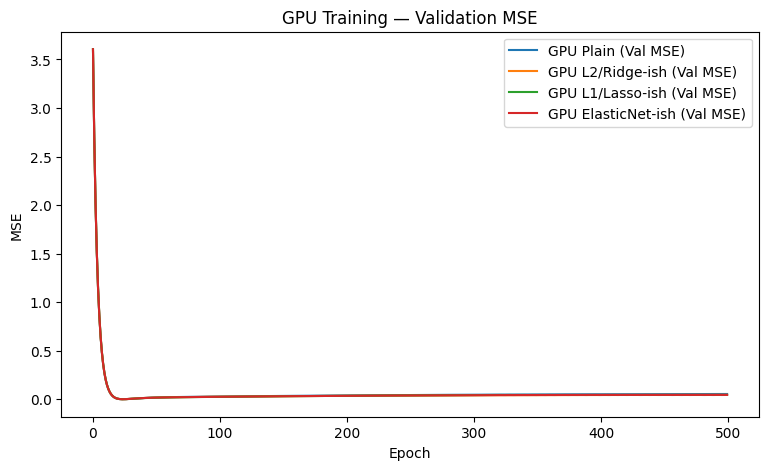

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- Sanity checks ----------
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Make sure your numpy arrays exist ----------
# These must already exist from your earlier split:
# X_train, y_train, X_val, y_val, X_test, y_test
print("X_train dtype:", X_train.dtype, "shape:", X_train.shape)
print("y_train dtype:", y_train.dtype, "shape:", y_train.shape)

# ---------- Standardize using TRAIN only (float32 everywhere) ----------
X_train_f = X_train.astype(np.float32)
X_val_f   = X_val.astype(np.float32)
X_test_f  = X_test.astype(np.float32)

y_train_f = y_train.astype(np.float32).reshape(-1,1)
y_val_f   = y_val.astype(np.float32).reshape(-1,1)
y_test_f  = y_test.astype(np.float32).reshape(-1,1)

mu = X_train_f.mean(axis=0, keepdims=True).astype(np.float32)
sigma = X_train_f.std(axis=0, keepdims=True).astype(np.float32)
sigma = np.where(sigma == 0, 1.0, sigma).astype(np.float32)

Xtr_s = ((X_train_f - mu) / sigma).astype(np.float32)
Xv_s  = ((X_val_f   - mu) / sigma).astype(np.float32)
Xt_s  = ((X_test_f  - mu) / sigma).astype(np.float32)

# Add intercept column so prediction is yhat = X @ w (bias included)
Xtr_np = np.c_[np.ones((len(Xtr_s), 1), dtype=np.float32), Xtr_s].astype(np.float32)
Xv_np  = np.c_[np.ones((len(Xv_s),  1), dtype=np.float32), Xv_s].astype(np.float32)
Xt_np  = np.c_[np.ones((len(Xt_s),  1), dtype=np.float32), Xt_s].astype(np.float32)

Xtr_t = torch.tensor(Xtr_np, device=device, dtype=torch.float32)
Xv_t  = torch.tensor(Xv_np,  device=device, dtype=torch.float32)
Xt_t  = torch.tensor(Xt_np,  device=device, dtype=torch.float32)

ytr_t = torch.tensor(y_train_f, device=device, dtype=torch.float32)
yv_t  = torch.tensor(y_val_f,   device=device, dtype=torch.float32)
yt_t  = torch.tensor(y_test_f,  device=device, dtype=torch.float32)

print("Tensor dtypes:", Xtr_t.dtype, ytr_t.dtype, "| devices:", Xtr_t.device, ytr_t.device)

# ---------- Training function ----------
def train_torch_linear(Xtr, ytr, Xv, yv, lr=0.05, epochs=500, l2=0.0, l1=0.0):
    w = torch.zeros((Xtr.shape[1], 1), device=Xtr.device, dtype=Xtr.dtype, requires_grad=True)
    tr_hist, va_hist = [], []

    for _ in range(epochs):
        yhat = Xtr @ w
        mse = torch.mean((ytr - yhat)**2)

        reg = 0.0
        if l2 > 0:
            reg = reg + l2 * torch.sum(w[1:]**2)      # don't regularize bias
        if l1 > 0:
            reg = reg + l1 * torch.sum(torch.abs(w[1:]))

        loss = mse + reg
        loss.backward()

        with torch.no_grad():
            w -= lr * w.grad
            w.grad.zero_()

            tr_hist.append(torch.mean((ytr - (Xtr @ w))**2).item())
            va_hist.append(torch.mean((yv  - (Xv  @ w))**2).item())

    return w.detach(), np.array(tr_hist), np.array(va_hist)

# ---------- Train ALL variants (this DEFINES va_plain etc.) ----------
w_plain, tr_plain, va_plain = train_torch_linear(Xtr_t, ytr_t, Xv_t, yv_t, l2=0.0,   l1=0.0)
w_l2,    tr_l2,    va_l2    = train_torch_linear(Xtr_t, ytr_t, Xv_t, yv_t, l2=0.01,  l1=0.0)
w_l1,    tr_l1,    va_l1    = train_torch_linear(Xtr_t, ytr_t, Xv_t, yv_t, l2=0.0,   l1=0.01)
w_en,    tr_en,    va_en    = train_torch_linear(Xtr_t, ytr_t, Xv_t, yv_t, l2=0.005, l1=0.005)

print("✅ Training done. va_plain length:", len(va_plain))

# ---------- Plot (will NOT NameError now) ----------
plt.figure(figsize=(9,5))
plt.plot(va_plain, label="GPU Plain (Val MSE)")
plt.plot(va_l2, label="GPU L2/Ridge-ish (Val MSE)")
plt.plot(va_l1, label="GPU L1/Lasso-ish (Val MSE)")
plt.plot(va_en, label="GPU ElasticNet-ish (Val MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("GPU Training — Validation MSE")
plt.legend()
plt.show()

GPU metrics table

In [ ]:
def torch_metrics(name, w):
    with torch.no_grad():
        ytr_p = (Xtr_t @ w).cpu().numpy().ravel()
        yv_p  = (Xv_t  @ w).cpu().numpy().ravel()
        yt_p  = (Xt_t  @ w).cpu().numpy().ravel()

    r2_tr = r2_score(y_train, ytr_p)
    return {
        "Model": name,
        "Device": "GPU (PyTorch)",
        "Train MSE": mean_squared_error(y_train, ytr_p),
        "Val MSE": mean_squared_error(y_val, yv_p),
        "Test MSE": mean_squared_error(y_test, yt_p),
        "Train R²": r2_tr,
        "Adj Train R²": adjusted_r2(r2_tr, len(y_train), X_train.shape[1]),
        "Test Pred": float(yt_p[0])
    }

gpu_results = pd.DataFrame([
    torch_metrics("Torch Plain", w_plain),
    torch_metrics("Torch L2 (Ridge-ish)", w_l2),
    torch_metrics("Torch L1 (Lasso-ish)", w_l1),
    torch_metrics("Torch ElasticNet-ish", w_en),
]).sort_values("Val MSE")

gpu_results


,Model,Device,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Pred
2,Torch L1 (Lasso-ish),GPU (PyTorch),0.000825,0.044217,0.035109,0.994767,0.989533,2.687374
3,Torch ElasticNet-ish,GPU (PyTorch),0.000819,0.044336,0.035082,0.994806,0.989613,2.687302
1,Torch L2 (Ridge-ish),GPU (PyTorch),0.000769,0.045164,0.034586,0.995122,0.990244,2.685973
0,Torch Plain,GPU (PyTorch),0.000560,0.053795,0.035495,0.996446,0.992893,2.688401


Final “CPU vs GPU” comparison dashboard

In [ ]:
final = pd.concat([cpu_results, gpu_results], ignore_index=True)
final.sort_values(["Device","Val MSE"])


,Model,Device,Train MSE,Val MSE,Test MSE,Train R²,Adj Train R²,Test Pred
0,Ridge α=1.0 (CPU),CPU (sklearn),0.005956,0.005133,0.010497,0.962207,0.924414,2.602454
1,Lasso α=0.05 (CPU),CPU (sklearn),0.003300,0.012981,0.003431,0.979061,0.958122,2.558579
2,ElasticNet α=0.05 l1=0.5 (CPU),CPU (sklearn),0.002079,0.020654,0.011592,0.986809,0.973619,2.607666
3,Ridge α=0.1 (CPU),CPU (sklearn),0.001024,0.039423,0.033284,0.993503,0.987007,2.682440
4,LinearRegression (CPU),CPU (sklearn),0.000533,0.057600,0.034844,0.996616,0.993232,2.686667
5,Torch L1 (Lasso-ish),GPU (PyTorch),0.000825,0.044217,0.035109,0.994767,0.989533,2.687374
6,Torch ElasticNet-ish,GPU (PyTorch),0.000819,0.044336,0.035082,0.994806,0.989613,2.687302
7,Torch L2 (Ridge-ish),GPU (PyTorch),0.000769,0.045164,0.034586,0.995122,0.990244,2.685973
8,Torch Plain,GPU (PyTorch),0.000560,0.053795,0.035495,0.996446,0.992893,2.688401
